# EMNIST Dataset

**Source**: [nist.gov](https://www.nist.gov/itl/products-and-services/emnist-dataset)

EMNIST is a set of handwritten character digits derived from the NIST database.

**Format**: Individual images of `28x28` pixels each. The dataset is provided in two formats. Images can be loaded using `scipy.io.loadmat function` or `.ToTensor()` transformation (see below).

A total of 6 splits is provided, see website for details.

In [ ]:
#| default_exp data
#| hide
import nbdev; nbdev.nbdev_export()

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Define the transformation to convert PIL images to tensors
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: torch.rot90(x, k=-1, dims=[1, 2])),  # Rotate 90 degrees counterclockwise
    transforms.Lambda(lambda x: torch.flip(x, dims=[2]))  # Flip horizontally to correct mirroring
])

# Load the EMNIST dataset (one test and one training set, using the "balanced" or "letters" split for example)
train_data = datasets.EMNIST(root="/data/datasets/HWR/emnist", split="letters", train=True, download=True, transform=transform)
train_dataloader = DataLoader(dataset=train_data, batch_size=8)
test_data = datasets.EMNIST(root="/data/datasets/HWR/emnist", split="letters", train=False, download=True, transform=transform)
test_dataloader = DataLoader(dataset=test_data, batch_size=8)

# Get a batch 
images, labels = next(iter(train_dataloader))



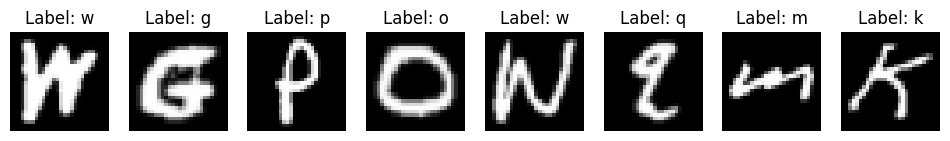

In [ ]:
label_to_char = {i: chr(96 + i) for i in range(1, 27)}  

# Plot the images side by side (with class labels as numbers)
plt.figure(figsize=(12, 4))
for i in range(len(images)):
    plt.subplot(1, 8, i+1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Label: {chr(96 + labels[i].item())}")
    plt.axis("off")
plt.show()

In [ ]:
# Inspect one of the tensors
# We find that these images have shape (1, 28, 28) and consist of [0 ... 1]-pixel values
print(images[0].shape)
print(images[0])

torch.Size([1, 28, 28])
tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0118, 0.0157, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0784, 0.4275, 0.4471, 0.1765, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.4471, 0.9608, 0.9922, 0.8392, 0.0196,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0784, 0.3922, 0.1294,
          0.0039, 0.0000, 0.0000,